In [150]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm

In [151]:
TRAIN_START = "2020-01-01"
TRAIN_END = "2025-06-30"

In [152]:
# Remove SHIB-USD since it has inf value
ticker_universe = ["BTC-USD", "ETH-USD", "BNB-USD", "XRP-USD", "SOL-USD", "TRX-USD", "ZEC-USD", "DOGE-USD", "XMR-USD", "LINK-USD", "ADA-USD", "XLM-USD", "BCH-USD", "LTC-USD", "NEAR-USD", "AVAX-USD", "HBAR-USD", "KCS-USD", "ALGO-USD", "DASH-USD"]

In [153]:
daily_prices = yf.download(tickers=ticker_universe, period="max", interval="1d")

[*********************100%***********************]  20 of 20 completed


In [154]:
daily_returns = (daily_prices["Close"] / daily_prices["Close"].shift() - 1).loc[TRAIN_START:TRAIN_END]
daily_volumes = daily_prices["Volume"].loc[TRAIN_START:TRAIN_END]

In [370]:
def featureX(ticker="BTC-USD"):
    rolling_periods = [14, 28, 45, 60, 90, 120]
    return pd.DataFrame({
        f"{x:03}AVG": daily_returns.shift().rolling(x).mean()[ticker] for x in rolling_periods
    } | {
        f"{x:03}INVSTD": 1 / daily_returns.shift().rolling(x).std()[ticker] for x in rolling_periods
    } | {
        f"{x:03}STD": daily_returns.shift().rolling(x).std()[ticker] for x in rolling_periods
    } | {
        f"{x:03}VOL": daily_volumes.pct_change(fill_method=None).shift().rolling(x).mean()[ticker] for x in rolling_periods
    } | {
        f"{x:03}{y:03}MUSIG": daily_returns.shift().rolling(x).mean()[ticker] * daily_returns.shift().rolling(y).std()[ticker] for x in rolling_periods for y in rolling_periods
    } | {
        f"{x:03}{y:03}SHPX": daily_returns.shift().rolling(x).mean()[ticker] / daily_returns.shift().rolling(y).std()[ticker] for x in rolling_periods for y in rolling_periods
    }).dropna()

featureX()

,014AVG,028AVG,045AVG,060AVG,090AVG,120AVG,014INVSTD,028INVSTD,045INVSTD,060INVSTD,...,090045SHPX,090060SHPX,090090SHPX,090120SHPX,120014SHPX,120028SHPX,120045SHPX,120060SHPX,120090SHPX,120120SHPX
Date,,,,,,,,,,,,,,,,,,,,,
2020-05-01,0.014772,0.009334,0.013227,0.002858,0.001031,0.003057,25.697272,27.116714,21.391616,14.557746,...,0.022053,0.015008,0.017835,0.019800,0.078565,0.082905,0.065401,0.044508,0.052892,0.058719
2020-05-02,0.016680,0.010501,0.012821,0.002657,0.001245,0.003504,25.882921,27.175865,21.473218,14.574865,...,0.026739,0.018149,0.021524,0.023941,0.090702,0.095232,0.075249,0.051075,0.060573,0.067374
2020-05-03,0.016053,0.010288,0.013077,0.003044,0.001458,0.003192,25.906345,27.204897,21.485510,14.575451,...,0.031322,0.021248,0.025194,0.028124,0.082692,0.086836,0.068581,0.046524,0.055163,0.061579
2020-05-04,0.016000,0.010324,0.008810,0.002936,0.001406,0.003033,25.881001,27.220311,25.714738,14.572105,...,0.036145,0.020483,0.024288,0.027111,0.078493,0.082555,0.077989,0.044195,0.052406,0.058497
2020-05-05,0.019177,0.007857,0.008820,0.002349,0.001559,0.003046,28.488786,28.739504,25.716105,14.603047,...,0.040096,0.022769,0.026950,0.030073,0.086786,0.087550,0.078339,0.044485,0.052655,0.058757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26,-0.000738,0.000006,0.000829,0.002259,0.002564,0.001935,57.616527,56.048110,58.088605,55.759785,...,0.148921,0.142951,0.114039,0.096767,0.111494,0.108459,0.112407,0.107901,0.086078,0.073041
2025-06-27,0.000808,0.000588,0.001022,0.002354,0.002882,0.002316,62.909720,57.390550,58.440254,55.908933,...,0.168430,0.161134,0.129934,0.110537,0.145708,0.132925,0.135356,0.129493,0.104420,0.088832
2025-06-28,0.000784,0.001186,0.000755,0.002157,0.003127,0.002291,62.913291,58.360511,58.786731,56.080789,...,0.183807,0.175346,0.141877,0.119919,0.144126,0.133696,0.134672,0.128473,0.103951,0.087863


In [401]:
weight_lag = 2
#weight_lag = 5

In [402]:
# def Regression():
#     X = pd.concat({ticker: featureX(ticker) for ticker in ticker_universe})
#     Y = daily_returns[::-1].rolling(window=weight_lag).sum()[::-1].unstack(level=0).dropna()
#     common_index = X.index.intersection(Y.index)
#     model = sm.OLS(Y.loc[common_index], X.loc[common_index]).fit()
#     return model

# regression_model = Regression()

In [403]:
def Regression(ticker="BTC-USD"):
    X = featureX(ticker)
    Y = daily_returns[ticker][::-1].rolling(window=weight_lag).sum()[::-1].dropna()
    common_index = X.index.intersection(Y.index)
    model = sm.OLS(Y.loc[common_index], X.loc[common_index]).fit()
    return model

regression_parameters = {ticker: Regression(ticker).params for ticker in ticker_universe}

In [404]:
(featureX() * regression_parameters["BTC-USD"]).sum(axis=1)

Date
2020-05-01    0.026166
2020-05-02    0.017123
2020-05-03    0.011027
2020-05-04    0.000538
2020-05-05    0.023385
                ...   
2025-06-26   -0.007728
2025-06-27   -0.008302
2025-06-28   -0.015757
2025-06-29   -0.014060
2025-06-30   -0.009287
Length: 1887, dtype: float64

In [405]:
def momentumWeights():
    signal = pd.DataFrame({ticker: (featureX(ticker) * regression_parameters[ticker]).sum(axis=1) for ticker in ticker_universe})
    ranked = signal.rank(axis=1)
    demeaned =  ranked.sub(ranked.mean(axis=1), axis=0)
    weights = demeaned.div(demeaned.abs().sum(axis=1), axis=0)
    lagged_weights = weights.iloc[::weight_lag].reindex(weights.index, method="ffill")
    return lagged_weights

momentum_weights = momentumWeights()
momentum_weights

,BTC-USD,ETH-USD,BNB-USD,XRP-USD,SOL-USD,TRX-USD,ZEC-USD,DOGE-USD,XMR-USD,LINK-USD,ADA-USD,XLM-USD,BCH-USD,LTC-USD,NEAR-USD,AVAX-USD,HBAR-USD,KCS-USD,ALGO-USD,DASH-USD
Date,,,,,,,,,,,,,,,,,,,,
2020-05-01,0.111111,0.041667,-0.041667,0.055556,NaN,0.013889,0.027778,-0.055556,0.069444,0.097222,-0.013889,0.000000,0.083333,-0.069444,NaN,NaN,-0.083333,-0.027778,-0.111111,-0.097222
2020-05-02,0.111111,0.041667,-0.041667,0.055556,NaN,0.013889,0.027778,-0.055556,0.069444,0.097222,-0.013889,0.000000,0.083333,-0.069444,NaN,NaN,-0.083333,-0.027778,-0.111111,-0.097222
2020-05-03,0.069444,0.097222,-0.041667,0.013889,NaN,-0.027778,0.055556,-0.097222,0.041667,0.111111,-0.055556,-0.013889,0.000000,-0.083333,NaN,NaN,-0.069444,0.027778,-0.111111,0.083333
2020-05-04,0.069444,0.097222,-0.041667,0.013889,NaN,-0.027778,0.055556,-0.097222,0.041667,0.111111,-0.055556,-0.013889,0.000000,-0.083333,NaN,NaN,-0.069444,0.027778,-0.111111,0.083333
2020-05-05,0.097222,-0.111111,-0.013889,0.055556,NaN,-0.027778,0.000000,-0.041667,0.069444,-0.083333,0.041667,0.013889,-0.069444,0.083333,NaN,NaN,0.027778,0.111111,-0.097222,-0.055556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26,-0.085000,0.065000,-0.075000,0.005000,0.025,0.095000,-0.095000,0.085000,-0.025000,-0.015000,0.075000,0.055000,-0.055000,-0.045000,0.015,-0.005,0.035000,-0.035000,0.045000,-0.065000
2025-06-27,-0.085000,0.065000,-0.075000,0.005000,0.025,0.095000,-0.095000,0.085000,-0.025000,-0.015000,0.075000,0.055000,-0.055000,-0.045000,0.015,-0.005,0.035000,-0.035000,0.045000,-0.065000
2025-06-28,-0.095000,0.075000,-0.055000,0.065000,-0.035,0.085000,-0.065000,-0.005000,-0.075000,0.005000,0.095000,0.055000,-0.085000,0.025000,0.015,-0.045,0.045000,-0.025000,0.035000,-0.015000


In [406]:
def grossMomentum():
    return (momentum_weights * daily_returns).sum(axis=1)

gross_momentum = grossMomentum()
gross_momentum.describe()

count    2008.000000
mean        0.005569
std         0.015857
min        -0.026358
25%        -0.001296
50%         0.002463
75%         0.008504
max         0.350794
dtype: float64

In [407]:
def sharpeRatio(x):
    return x.mean() / x.std() * np.sqrt(252)

In [408]:
f"Sharpe Ratio: {sharpeRatio(gross_momentum):.2f}"

'Sharpe Ratio: 5.58'

In [409]:
def turnOver(weights):
    return (weights - weights.shift()).abs().sum(axis=1)

def netMomentum():
    turnover = turnOver(momentum_weights)
    net_momentum = gross_momentum.subtract(turnover * 0.002, fill_value=0)
    return net_momentum

net_momentum = netMomentum()
net_momentum.describe()

count    2008.000000
mean        0.004935
std         0.015814
min        -0.027558
25%        -0.001923
50%         0.001890
75%         0.007739
max         0.349372
dtype: float64

In [410]:
f"Sharpe Ratio: {sharpeRatio(net_momentum):.2f}"

'Sharpe Ratio: 4.95'

C:\Users\jibri\AppData\Local\Temp\ipykernel_19576\3697490901.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return x.mean() / x.std() * np.sqrt(252)


<Axes: xlabel='Date'>

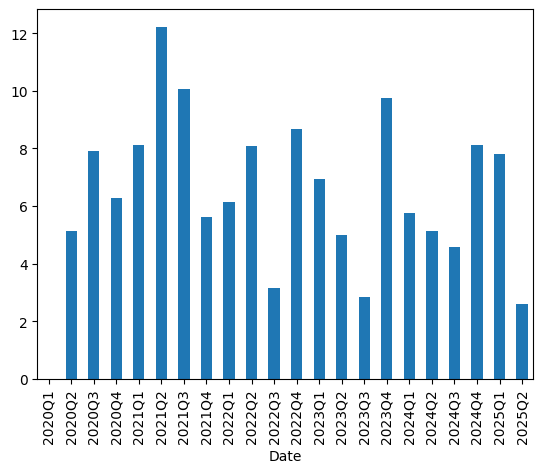

In [411]:
gross_momentum.resample("QE").apply(sharpeRatio).to_period("Q").plot(kind="bar")

C:\Users\jibri\AppData\Local\Temp\ipykernel_19576\3697490901.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return x.mean() / x.std() * np.sqrt(252)


<Axes: xlabel='Date'>

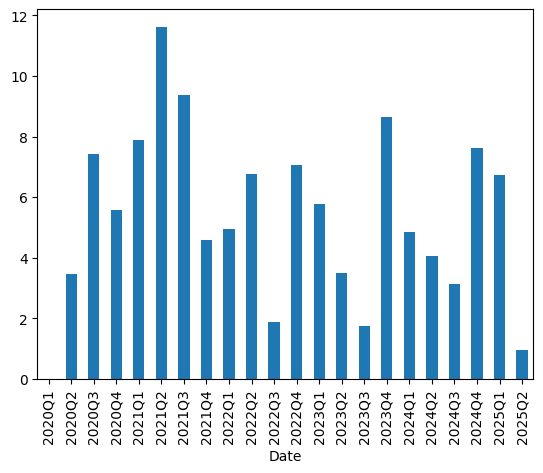

In [412]:
net_momentum.resample("QE").apply(sharpeRatio).to_period("Q").plot(kind="bar")

<Axes: title={'center': 'Momentum Strategy Drawdown'}, xlabel='Date', ylabel='Drawdown'>

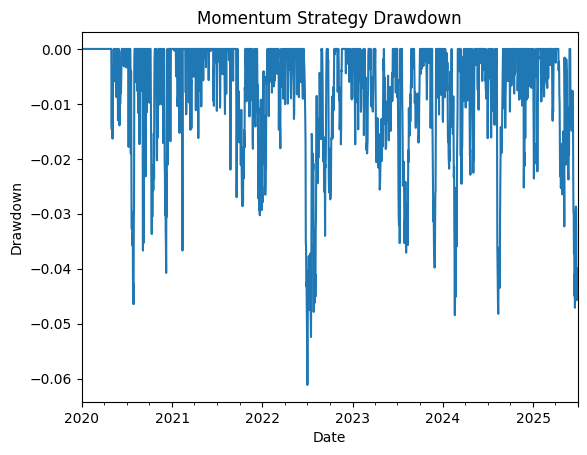

In [413]:
drawdown = (1 + net_momentum).cumprod() / (1 + net_momentum).cumprod().cummax() - 1
drawdown.plot(title="Momentum Strategy Drawdown", ylabel="Drawdown")

<Axes: >

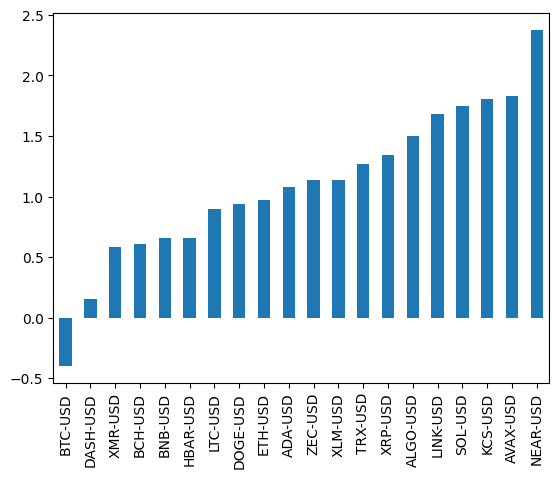

In [414]:
net_momentum_tickers = (momentum_weights * daily_returns).subtract((momentum_weights - momentum_weights.shift()).abs() * 0.002, fill_value=0)
net_momentum_tickers.apply(sharpeRatio).sort_values().plot(kind="bar")